# 02 - Inteligencia de Priorizacao

> **Objetivo:** Criar a regra de negocio que o motor de disparos seguira.
> Propor um algoritmo (score ou ranking) que escolha automaticamente
> os **dois melhores** telefones para receberem a mensagem.

**Abordagem:**
1. Consolidar o ranking de confiabilidade dos sistemas (Parte 1)
2. Explicar matematicamente por que um sistema e melhor que outro
3. Calibrar pesos do score composto via **Regressao Logistica**
4. Implementar o algoritmo de escolha dos 2 melhores telefones por CPF
5. Validar o algoritmo contra baseline aleatorio

**Correcoes desta versao:**
- Grid search para otimizar half-life do decaimento temporal
- Split temporal (cronologico) em vez de aleatorio
- Metricas de capacidade preditiva: AUC-ROC, LogLoss, MCC, Acuracia

**Limitacoes da Regressao Logistica:**
- Assume linearidade no log-odds
- Coeficientes refletem associacao, nao causalidade

In [1]:
# ============================================================
# 1. IMPORTS E CONFIGURACAO
# ============================================================
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, log_loss, accuracy_score, 
    matthews_corrcoef, confusion_matrix
)

import utils as u

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print('Imports OK.')

Imports OK.


---
## 2. Carregamento dos Dados e Artefatos da Parte 1

In [2]:
# ============================================================
# 2.1 CARREGAR ARTEFATOS
# ============================================================
OUTPUT_DIR = u.BASE_DIR / 'data' / 'processed'

try:
    with open(OUTPUT_DIR / 'metricas_sistema.pkl', 'rb') as f:
        metricas = pickle.load(f)
    print('metricas_sistema.pkl carregado')
except FileNotFoundError:
    print('Artefatos nao encontrados. Execute o Notebook 01 primeiro.')
    raise

# Recarregar dados brutos para features
df_disparo, df_telefone = u.carregar_dados()

# Aplicar filtros consistentes com Notebook 01
df_disparo = u.filtrar_status_invalidos(df_disparo)
df_telefone = u.filtrar_telefones_fixos(df_telefone)

print('Disparos:', df_disparo.shape)
print('Telefones:', df_telefone.shape)
print('Metricas por sistema:', metricas.shape)

metricas_sistema.pkl carregado


Filtrando status=processing: 392,921 -> 389,761 (-3,160)
Filtrando telefones fixos: 283,289 -> 283,289 (-0)
Disparos: (389761, 16)
Telefones: (283289, 11)
Metricas por sistema: (6, 11)


---
## 3. Ranking de Sistemas — Explicacao Matematica

**Entregavel do enunciado:** Tabela ou Score de ranking das fontes.
**Explicar matematicamente por que o sistema X e melhor que o sistema Y.**

### Por que Wilson Score?

A taxa bruta de leitura (`read / total`) pode enganar quando volumes
sao muito diferentes.

O **Intervalo de Confianca de Wilson** fornece uma estimativa
conservadora da taxa real, penalizando sistemas com pouca evidencia.
Usamos o **limite inferior** (95% de confianca) como score primario.

In [3]:
# ============================================================
# 3.1 TABELA CONSOLIDADA
# ============================================================
from statsmodels.stats.proportion import proportion_confint

# Recalcular IC completo para exibicao
def calcular_ic_completo(row):
    ci_low, ci_high = proportion_confint(
        row['read'], row['total_disparos'],
        alpha=0.05, method='wilson'
    )
    return pd.Series({'ci_low': ci_low, 'ci_high': ci_high})

metricas[['ci_low', 'ci_high']] = metricas.apply(calcular_ic_completo, axis=1)

# Ordenar
metricas = metricas.sort_values('wilson_lower_read', ascending=False).reset_index(drop=True)

# Criar coluna de explicacao
def explicar_ranking(row):
    if row['total_disparos'] < 100:
        return f"Volume baixo (n={row['total_disparos']}). IC amplo: [{row['ci_low']:.2f}, {row['ci_high']:.2f}]. Pouca confianca."
    elif row['total_disparos'] < 1000:
        return f"Volume moderado (n={row['total_disparos']}). IC: [{row['ci_low']:.2f}, {row['ci_high']:.2f}]."
    else:
        return f"Alto volume (n={row['total_disparos']:,}). IC apertado: [{row['ci_low']:.2f}, {row['ci_high']:.2f}]. Alto grau de confianca."

metricas['explicacao'] = metricas.apply(explicar_ranking, axis=1)

print('=== TOP 15 SISTEMAS (com explicacao matematica) ===')
metricas[['id_sistema', 'total_disparos', 'read', 'taxa_leitura',
          'wilson_lower_read', 'explicacao']].head(15)

=== TOP 15 SISTEMAS (com explicacao matematica) ===


,id_sistema,total_disparos,read,taxa_leitura,wilson_lower_read,explicacao
0,-4704067261970591609,196479,152720,0.777284,0.775439,"Alto volume (n=196,479). IC apertado: [0.78, 0..."
1,3094574413675758272,686843,423958,0.617256,0.616106,"Alto volume (n=686,843). IC apertado: [0.62, 0..."
2,-2757366171786647144,10872,5044,0.463944,0.454584,"Alto volume (n=10,872). IC apertado: [0.45, 0...."
3,4458959843028638627,52925,16881,0.318961,0.315003,"Alto volume (n=52,925). IC apertado: [0.32, 0...."
4,1257277410380486863,1548950,171706,0.110853,0.110360,"Alto volume (n=1,548,950). IC apertado: [0.11,..."
5,-133612832286195827,3788514,323942,0.085506,0.085225,"Alto volume (n=3,788,514). IC apertado: [0.09,..."


---
## 4. Preparacao das Features por Telefone

Para construir o score composto, extraimos 3 componentes:

| Feature | Descricao |
|---|---|
| `score_origem` | Maximo Wilson score entre os sistemas do telefone |
| `decaimento_temporal` | Funcao exponencial decrescente da idade do dado |
| `penalidade_proprietarios` | 1 / n_proprietarios |

**Nesta secao tambem calculamos o half-life empirico a partir dos dados.**

In [4]:
# ============================================================
# 4.1 CRIAR DICIONARIO DE SCORE POR SISTEMA
# ============================================================
sistema_scores = dict(zip(metricas['id_sistema'], metricas['wilson_lower_read']))
print(f'Scores disponiveis para {len(sistema_scores)} sistemas.')

Scores disponiveis para 6 sistemas.


In [5]:
# ============================================================
# 4.2 EXTRAIR FEATURES POR TELEFONE
# ============================================================
def extrair_features_telefone(row):
    sistemas = row['telefone_aparicoes']
    if isinstance(sistemas, (list, np.ndarray)) and len(sistemas) > 0:
        scores = [sistema_scores.get(s['id_sistema'], 0) for s in sistemas]
        score_origem = max(scores) if scores else 0
        
        datas = [s['registro_data_atualizacao'] for s in sistemas 
                 if 'registro_data_atualizacao' in s and s['registro_data_atualizacao'] is not None]
        data_mais_recente = max(datas) if datas else None
    else:
        score_origem = 0
        data_mais_recente = None
    
    n_proprietarios = row['telefone_proprietarios_quantidade']
    penalidade = 1 / max(n_proprietarios, 1)
    
    return pd.Series({
        'telefone_numero': row['telefone_numero'],
        'score_origem': score_origem,
        'data_atualizacao': data_mais_recente,
        'n_proprietarios': n_proprietarios,
        'penalidade_proprietarios': penalidade,
        'telefone_ddd': row['telefone_ddd'],
    })

print('Extraindo features para cada telefone...')
df_features = df_telefone.apply(extrair_features_telefone, axis=1)
print('Features extraidas:', df_features.shape)
df_features.head()

Extraindo features para cada telefone...


Features extraidas: (283289, 6)


,telefone_numero,score_origem,data_atualizacao,n_proprietarios,penalidade_proprietarios,telefone_ddd
0,-6.862804e+18,0.110360,2024-10-30,1.0,1.0,-1.181434e+18
1,3.856003e+18,0.616106,2023-09-01,1.0,1.0,-1.181434e+18
2,8.067166e+18,0.616106,2025-10-08,1.0,1.0,-1.181434e+18
3,1.478900e+18,0.315003,2025-02-22,1.0,1.0,-1.181434e+18
4,-6.105816e+18,0.110360,2023-06-06,1.0,1.0,-1.181434e+18


---
## 5. Half-life Empirico vs. Otimizado

Antes de calibrar os pesos, precisamos definir o **half-life** do decaimento
temporal. Em vez de arbitrar 180 dias, vamos:

1. **Calcular o half-life empirico** a partir da curva de decaimento observada
2. **Buscar o half-life otimizado** via grid search que maximiza a capacidade preditiva

In [6]:
# ============================================================
# 5.0 CALCULAR HALF-LIFE EMPIRICO
# ============================================================
# Usamos a base de disparos + dimensao para calcular o decaimento real
# Vamos usar a mesma logica da Parte 1 (Notebook 01)

# Primeiro, adicionar dias de atualizacao ao df_features
data_referencia = df_disparo['envio_datahora'].max()
df_features['dias_atualizacao'] = (
    pd.to_datetime(data_referencia) - pd.to_datetime(df_features['data_atualizacao'])
).dt.days
df_features['dias_atualizacao'] = df_features['dias_atualizacao'].fillna(9999).clip(lower=0)

# Explodir aparicoes para calcular decaimento por faixa
df_aparicoes = u.explodir_aparicoes(df_telefone)
df_temp = df_disparo.merge(
    df_aparicoes,
    left_on='contato_telefone',
    right_on='telefone_numero',
    how='inner'
)

# Calcular dias desde atualizacao
df_temp['dias_desde_atualizacao'] = (
    pd.to_datetime(df_temp['envio_datahora']) - pd.to_datetime(df_temp['registro_data_atualizacao'])
).dt.days
df_temp = df_temp[df_temp['dias_desde_atualizacao'] >= 0]

# Criar bins menores para detectar ponto de meia-vida
bins_finos = [0, 30, 60, 90, 120, 150, 180, 240, 300, 365, 500, 9999]
labels_finos = ['0-30d', '30-60d', '60-90d', '90-120d', '120-150d', '150-180d',
                '180-240d', '240-300d', '300-365d', '365-500d', '500d+']

df_temp['faixa_fina'] = pd.cut(df_temp['dias_desde_atualizacao'], bins=bins_finos, labels=labels_finos)
decaimento_fino = df_temp.groupby('faixa_fina').agg(
    total=('status_disparo', 'count'),
    read=('status_disparo', lambda x: (x == 'read').sum()),
).reset_index()
decaimento_fino['taxa_leitura'] = decaimento_fino['read'] / decaimento_fino['total']

print('=== DECAIMENTO POR FAIXA (detalhado) ===')
print(decaimento_fino)

# Encontrar half-life empirico: ponto onde a taxa cai pela metade
taxa_max = decaimento_fino['taxa_leitura'].iloc[0]
taxa_min = decaimento_fino['taxa_leitura'].min()
metade = taxa_max - (taxa_max - taxa_min) / 2

# Interpolar
half_life_empirico = None
for i in range(len(decaimento_fino) - 1):
    if decaimento_fino['taxa_leitura'].iloc[i] >= metade >= decaimento_fino['taxa_leitura'].iloc[i+1]:
        # Interpolacao linear simples entre os pontos medios das faixas
        x1 = bins_finos[i] + (bins_finos[i+1] - bins_finos[i]) / 2
        x2 = bins_finos[i+1] + (bins_finos[i+2] - bins_finos[i+1]) / 2
        y1 = decaimento_fino['taxa_leitura'].iloc[i]
        y2 = decaimento_fino['taxa_leitura'].iloc[i+1]
        half_life_empirico = x1 + (metade - y1) * (x2 - x1) / (y2 - y1)
        break

if half_life_empirico is None:
    half_life_empirico = 180  # fallback

print()
print(f'Taxa maxima (mais recente): {taxa_max:.3f}')
print(f'Taxa minima (mais antigo):  {taxa_min:.3f}')
print(f'Meta (meia-vida):           {metade:.3f}')
print(f'Half-life empirico:         {half_life_empirico:.0f} dias')

Telefones únicos: 283,289
Linhas após explosão: 1,529,772
Sistemas únicos: 6


=== DECAIMENTO POR FAIXA (detalhado) ===
   faixa_fina   total    read  taxa_leitura
0       0-30d    8881    6474      0.728972
1      30-60d   18373   13610      0.740761
2      60-90d   29737   22089      0.742812
3     90-120d   39249   29566      0.753293
4    120-150d  390947  294950      0.754450
5    150-180d   54948   19978      0.363580
6    180-240d  118199   44463      0.376171
7    240-300d  118535   54344      0.458464
8    300-365d  119880   54308      0.453020
9    365-500d  215029   69798      0.324598
10      500d+  484282  178717      0.369035

Taxa maxima (mais recente): 0.729
Taxa minima (mais antigo):  0.325
Meta (meia-vida):           0.527
Half-life empirico:         152 dias


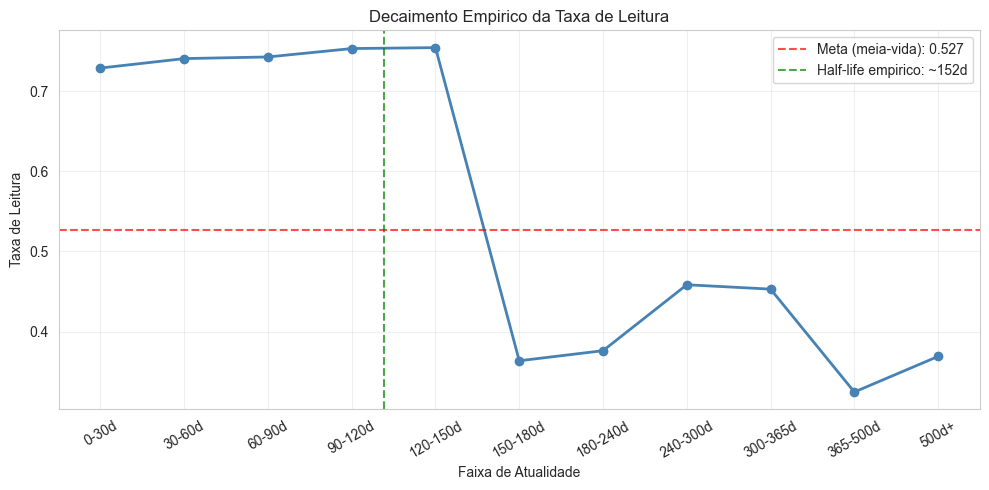

In [7]:
# ============================================================
# 5.0 VISUALIZACAO DO DECAIMENTO EMPIRICO
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = range(len(decaimento_fino))
ax.plot(x_pos, decaimento_fino['taxa_leitura'], marker='o', color='steelblue', linewidth=2)

# Marcar half-life empirico
ax.axhline(metade, color='red', linestyle='--', alpha=0.7, label=f'Meta (meia-vida): {metade:.3f}')
ax.axvline(half_life_empirico / 45, color='green', linestyle='--', alpha=0.7, label=f'Half-life empirico: ~{half_life_empirico:.0f}d')

ax.set_xticks(x_pos)
ax.set_xticklabels(decaimento_fino['faixa_fina'], rotation=30)
ax.set_ylabel('Taxa de Leitura')
ax.set_xlabel('Faixa de Atualidade')
ax.set_title('Decaimento Empirico da Taxa de Leitura')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5.1 Grid Search do Half-life com Split Temporal

Buscamos o half-life que maximiza a **capacidade preditiva** do modelo.
Como os dados tem dimensao cronologica, usamos **split temporal**:
treinamos no passado, validamos no futuro. Isso evita data leakage e
simula a realidade operacional.

Para cada valor de half-life, calculamos:
- AUC-ROC (discriminacao)
- LogLoss (calibracao probabilistica)
- MCC (correlacao robusta para classes desbalanceadas)
- Acuracia (referencia simples)

In [8]:
# ============================================================
# 5.1 GRID SEARCH DE HALF-LIFE
# ============================================================
# Grid de half-lives a testar
half_lives_grid = [30, 60, 90, 120, 180, 270, 365]

# Preparar dataset base (sem decaimento ainda)
df_train_base = df_disparo.merge(
    df_features[['telefone_numero', 'score_origem', 'penalidade_proprietarios', 'dias_atualizacao']],
    left_on='contato_telefone',
    right_on='telefone_numero',
    how='inner'
)
df_train_base['y_read'] = (df_train_base['status_disparo'] == 'read').astype(int)

# Split temporal: ordenar por data e cortar em 80/20
df_train_base = df_train_base.sort_values('envio_datahora').reset_index(drop=True)
corte_idx = int(len(df_train_base) * 0.8)

print(f'Total de observacoes: {len(df_train_base):,}')
print(f'Corte temporal: {corte_idx:,} (treino) / {len(df_train_base) - corte_idx:,} (validacao)')
print()

# Funcao para calcular decaimento com dado half-life
def calcular_decaimento(dias, half_life):
    return np.exp(-np.log(2) * dias / half_life)

# Grid search
resultados_grid = []

for hl in half_lives_grid:
    # Calcular decaimento
    decaimento = calcular_decaimento(df_train_base['dias_atualizacao'].values, hl)
    
    # Features
    X = np.column_stack([
        df_train_base['score_origem'].values,
        decaimento,
        df_train_base['penalidade_proprietarios'].values
    ])
    y = df_train_base['y_read'].values
    
    # Split temporal
    X_train, X_val = X[:corte_idx], X[corte_idx:]
    y_train, y_val = y[:corte_idx], y[corte_idx:]
    
    # Padronizar
    scaler_hl = StandardScaler()
    X_train_s = scaler_hl.fit_transform(X_train)
    X_val_s = scaler_hl.transform(X_val)
    
    # Treinar
    modelo_hl = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
    modelo_hl.fit(X_train_s, y_train)
    
    # Predicoes
    y_proba = modelo_hl.predict_proba(X_val_s)[:, 1]
    y_pred = modelo_hl.predict(X_val_s)
    
    # Metricas
    auc = roc_auc_score(y_val, y_proba)
    ll = log_loss(y_val, y_proba)
    acc = accuracy_score(y_val, y_pred)
    mcc = matthews_corrcoef(y_val, y_pred)
    
    resultados_grid.append({
        'half_life': hl,
        'auc_roc': auc,
        'log_loss': ll,
        'acuracia': acc,
        'mcc': mcc
    })

df_grid = pd.DataFrame(resultados_grid)
print('=== RESULTADOS DO GRID SEARCH ===')
print(df_grid.round(4).to_string(index=False))

Total de observacoes: 342,697
Corte temporal: 274,157 (treino) / 68,540 (validacao)



C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


=== RESULTADOS DO GRID SEARCH ===
 half_life  auc_roc  log_loss  acuracia    mcc
        30   0.5458    0.6237    0.6294 0.0888
        60   0.5440    0.6260    0.6343 0.0899
        90   0.5429    0.6281    0.6384 0.0895
       120   0.5420    0.6298    0.6416 0.0891
       180   0.5394    0.6319    0.6481 0.0853
       270   0.5384    0.6329    0.6552 0.0863
       365   0.5383    0.6324    0.6578 0.0862


C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


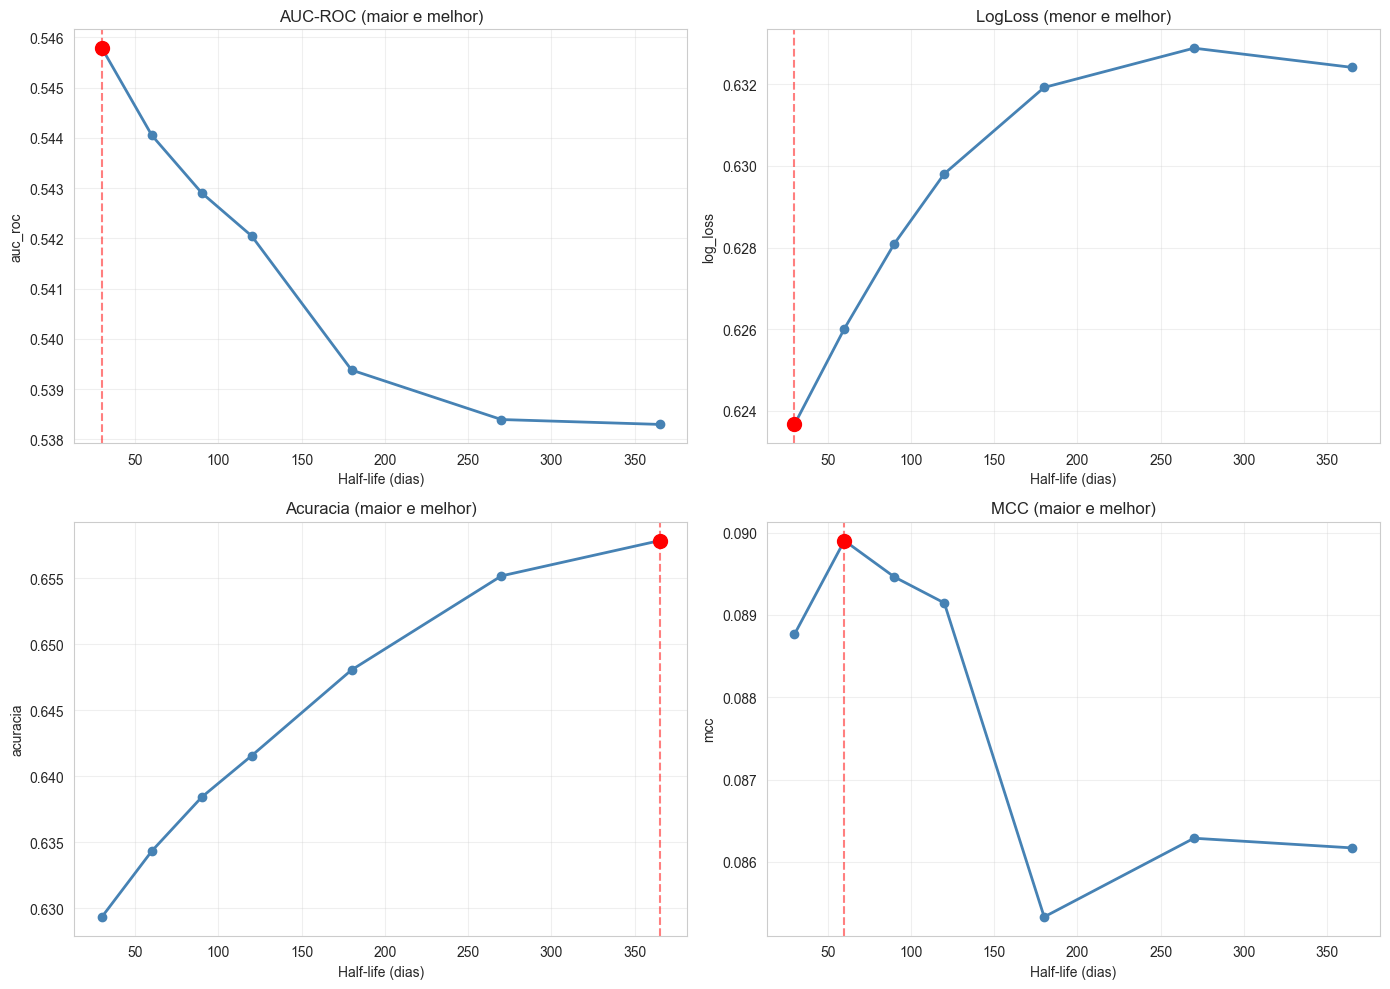

In [9]:
# ============================================================
# 5.1 VISUALIZACAO DO GRID SEARCH
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metricas_plot = [
    ('auc_roc', 'AUC-ROC (maior e melhor)', 'max'),
    ('log_loss', 'LogLoss (menor e melhor)', 'min'),
    ('acuracia', 'Acuracia (maior e melhor)', 'max'),
    ('mcc', 'MCC (maior e melhor)', 'max')
]

for ax, (col, titulo, direcao) in zip(axes.flat, metricas_plot):
    ax.plot(df_grid['half_life'], df_grid[col], marker='o', color='steelblue', linewidth=2)
    
    # Marcar o melhor
    if direcao == 'max':
        idx_melhor = df_grid[col].idxmax()
    else:
        idx_melhor = df_grid[col].idxmin()
    
    melhor_hl = df_grid.loc[idx_melhor, 'half_life']
    melhor_val = df_grid.loc[idx_melhor, col]
    ax.axvline(melhor_hl, color='red', linestyle='--', alpha=0.5)
    ax.scatter([melhor_hl], [melhor_val], color='red', s=100, zorder=5)
    
    ax.set_xlabel('Half-life (dias)')
    ax.set_ylabel(col)
    ax.set_title(titulo)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5.2 Comparacao: Half-life Empirico vs. Otimizado

Agora comparamos o half-life calculado empiricamente (da curva de
decaimento) com o valor que maximiza a capacidade preditiva.

In [10]:
# ============================================================
# 5.2 COMPARAR HALF-LIFE EMPIRICO VS OTIMIZADO
# ============================================================
# Encontrar o melhor half-life segundo cada metrica
melhor_auc = df_grid.loc[df_grid['auc_roc'].idxmax()]
melhor_logloss = df_grid.loc[df_grid['log_loss'].idxmin()]
melhor_mcc = df_grid.loc[df_grid['mcc'].idxmax()]

print('=== HALF-LIFE EMPIRICO ===')
print(f'Valor: {half_life_empirico:.0f} dias')
print(f'(Ponto onde a taxa de leitura cai pela metade na curva observada)')
print()

print('=== HALF-LIFE OTIMIZADO ===')
print(f'Melhor por AUC-ROC:   {melhor_auc["half_life"]:.0f} dias (AUC={melhor_auc["auc_roc"]:.4f})')
print(f'Melhor por LogLoss:   {melhor_logloss["half_life"]:.0f} dias (LL={melhor_logloss["log_loss"]:.4f})')
print(f'Melhor por MCC:       {melhor_mcc["half_life"]:.0f} dias (MCC={melhor_mcc["mcc"]:.4f})')
print()

# Escolher o half-life final
# Priorizamos AUC-ROC (discriminacao) e LogLoss (calibracao)
# Se forem diferentes, usamos AUC-ROC como tie-breaker
if melhor_auc['half_life'] == melhor_logloss['half_life']:
    HALF_LIFE_FINAL = int(melhor_auc['half_life'])
    print(f'Consenso: AUC-ROC e LogLoss concordam em {HALF_LIFE_FINAL} dias')
else:
    # Escolher o que tem melhor rank medio
    df_grid['rank_auc'] = df_grid['auc_roc'].rank(ascending=False)
    df_grid['rank_ll'] = df_grid['log_loss'].rank(ascending=True)
    df_grid['rank_mcc'] = df_grid['mcc'].rank(ascending=False)
    df_grid['rank_medio'] = (df_grid['rank_auc'] + df_grid['rank_ll'] + df_grid['rank_mcc']) / 3
    
    melhor_rank = df_grid.loc[df_grid['rank_medio'].idxmin()]
    HALF_LIFE_FINAL = int(melhor_rank['half_life'])
    print(f'Divergencia entre metricas. Melhor rank medio: {HALF_LIFE_FINAL} dias')
    print(f'  AUC-ROC: {melhor_rank["auc_roc"]:.4f}')
    print(f'  LogLoss: {melhor_rank["log_loss"]:.4f}')
    print(f'  MCC:     {melhor_rank["mcc"]:.4f}')

print()
print(f'Half-life final escolhido: {HALF_LIFE_FINAL} dias')

=== HALF-LIFE EMPIRICO ===
Valor: 152 dias
(Ponto onde a taxa de leitura cai pela metade na curva observada)

=== HALF-LIFE OTIMIZADO ===
Melhor por AUC-ROC:   30 dias (AUC=0.5458)
Melhor por LogLoss:   30 dias (LL=0.6237)
Melhor por MCC:       60 dias (MCC=0.0899)

Consenso: AUC-ROC e LogLoss concordam em 30 dias

Half-life final escolhido: 30 dias


---
## 5.3 Treinar Modelo Final com Half-life Otimizado

Usando o half-life selecionado e o split temporal, treinamos o modelo
final e avaliamos com todas as metricas de capacidade preditiva.

In [11]:
# ============================================================
# 5.3 TREINAR MODELO FINAL
# ============================================================
# Calcular decaimento com half-life final
decaimento_final = calcular_decaimento(df_train_base['dias_atualizacao'].values, HALF_LIFE_FINAL)

# Features finais
feature_cols = ['score_origem', 'decaimento_temporal', 'penalidade_proprietarios']
X_full = np.column_stack([
    df_train_base['score_origem'].values,
    decaimento_final,
    df_train_base['penalidade_proprietarios'].values
])
y_full = df_train_base['y_read'].values

# Split temporal (mesmo corte de antes)
X_train_final, X_val_final = X_full[:corte_idx], X_full[corte_idx:]
y_train_final, y_val_final = y_full[:corte_idx], y_full[corte_idx:]

print(f'Treino: {len(X_train_final):,} observacoes')
print(f'Validacao: {len(X_val_final):,} observacoes')
print(f'Periodo treino: {df_train_base["envio_datahora"].iloc[0]} a {df_train_base["envio_datahora"].iloc[corte_idx-1]}')
print(f'Periodo validacao: {df_train_base["envio_datahora"].iloc[corte_idx]} a {df_train_base["envio_datahora"].iloc[-1]}')
print()

# Padronizar
scaler_final = StandardScaler()
X_train_s_final = scaler_final.fit_transform(X_train_final)
X_val_s_final = scaler_final.transform(X_val_final)

# Treinar
modelo_final = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
modelo_final.fit(X_train_s_final, y_train_final)

# Predicoes
y_proba_final = modelo_final.predict_proba(X_val_s_final)[:, 1]
y_pred_final = modelo_final.predict(X_val_s_final)

# Metricas
auc_final = roc_auc_score(y_val_final, y_proba_final)
ll_final = log_loss(y_val_final, y_proba_final)
acc_final = accuracy_score(y_val_final, y_pred_final)
mcc_final = matthews_corrcoef(y_val_final, y_pred_final)

print('=== METRICAS DE CAPACIDADE PREDITIVA ===')
print(f'AUC-ROC:   {auc_final:.4f}  (discriminacao)')
print(f'LogLoss:   {ll_final:.4f}  (calibracao probabilistica)')
print(f'Acuracia:  {acc_final:.4f}  (classificacao correta)')
print(f'MCC:       {mcc_final:.4f}  (correlacao robusta)')
print()

# Interpretacao das metricas
print('=== INTERPRETACAO ===')
print(f'AUC-ROC: 0.5 = aleatorio, 0.7 = razoavel, 0.8 = bom, 0.9 = excelente')
print(f'         Valor obtido: {auc_final:.4f}')
print()
print(f'LogLoss: quanto menor, melhor. Penaliza confianca errada.')
print(f'         Valor obtido: {ll_final:.4f}')
print()
print(f'MCC: -1 (pior) a +1 (perfeito). 0 = aleatorio.')
print(f'     Valor obtido: {mcc_final:.4f}')
print()

# Coeficientes
print('Coeficientes (features padronizadas):')
for feat, coef in zip(feature_cols, modelo_final.coef_[0]):
    print(f'  {feat}: {coef:.4f}')
print(f'Intercepto: {modelo_final.intercept_[0]:.4f}')

Treino: 274,157 observacoes
Validacao: 68,540 observacoes
Periodo treino: 2025-09-03 09:43:05 a 2026-03-18 14:46:28
Periodo validacao: 2026-03-18 14:46:28 a 2026-04-18 14:20:33

=== METRICAS DE CAPACIDADE PREDITIVA ===
AUC-ROC:   0.5458  (discriminacao)
LogLoss:   0.6237  (calibracao probabilistica)
Acuracia:  0.6294  (classificacao correta)
MCC:       0.0888  (correlacao robusta)

=== INTERPRETACAO ===
AUC-ROC: 0.5 = aleatorio, 0.7 = razoavel, 0.8 = bom, 0.9 = excelente
         Valor obtido: 0.5458

LogLoss: quanto menor, melhor. Penaliza confianca errada.
         Valor obtido: 0.6237

MCC: -1 (pior) a +1 (perfeito). 0 = aleatorio.
     Valor obtido: 0.0888

Coeficientes (features padronizadas):
  score_origem: 0.3754
  decaimento_temporal: 0.0842
  penalidade_proprietarios: 0.0412
Intercepto: 0.9950


C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


---
## 5.4 Converter Coeficientes para Pesos Interpretaveis

Os coeficientes na escala padronizada sao dificeis de interpretar como
pesos de score. Convertemos para a escala original e normalizamos.

In [12]:
# ============================================================
# 5.4 CONVERTER PARA PESOS
# ============================================================
# Para features padronizadas: coef reflete impacto de 1 std-dev
# Para converter a escala original: peso = coef / std_feature
# Depois normalizamos para somar 1

X_train_df = pd.DataFrame(X_train_final, columns=feature_cols)
stds = X_train_df.std()
pesos_brutos = modelo_final.coef_[0] / stds.values

# Normalizar para somar 1 (valores absolutos)
pesos_normalizados = np.abs(pesos_brutos) / np.abs(pesos_brutos).sum()

pesos_df = pd.DataFrame({
    'feature': feature_cols,
    'coef_padronizado': modelo_final.coef_[0],
    'peso_calibrado': pesos_normalizados
})

print('=== PESOS CALIBRADOS ===')
print(pesos_df)
print()
print('Soma dos pesos:', f'{pesos_normalizados.sum():.3f}')
print()

# Armazenar pesos
PESO_ORIGEM = pesos_normalizados[0]
PESO_TEMPO = pesos_normalizados[1]
PESO_PROPRIETARIOS = pesos_normalizados[2]

print('Pesos finais:')
print('  score_origem:', f'{PESO_ORIGEM:.3f}')
print('  decaimento_temporal:', f'{PESO_TEMPO:.3f}')
print('  penalidade_proprietarios:', f'{PESO_PROPRIETARIOS:.3f}')
print()
print(f'Half-life usado: {HALF_LIFE_FINAL} dias')

=== PESOS CALIBRADOS ===
                    feature  coef_padronizado  peso_calibrado
0              score_origem          0.375428        0.130496
1       decaimento_temporal          0.084194        0.860509
2  penalidade_proprietarios          0.041241        0.008996

Soma dos pesos: 1.000

Pesos finais:
  score_origem: 0.130
  decaimento_temporal: 0.861
  penalidade_proprietarios: 0.009

Half-life usado: 30 dias


---
## 6. Score Composto e Algoritmo de Escolha

Aplicamos os pesos calibrados com o half-life otimizado.

In [13]:
# ============================================================
# 6.1 APLICAR SCORE COMPOSTO
# ============================================================
# Recalcular decaimento com half-life final nos features
df_features['decaimento_temporal'] = np.exp(-np.log(2) * df_features['dias_atualizacao'] / HALF_LIFE_FINAL)

def calcular_score_composto(row, w1, w2, w3):
    return (
        w1 * row['score_origem'] +
        w2 * row['decaimento_temporal'] +
        w3 * row['penalidade_proprietarios']
    )

df_features['score_calibrado'] = df_features.apply(
    lambda row: calcular_score_composto(row, PESO_ORIGEM, PESO_TEMPO, PESO_PROPRIETARIOS),
    axis=1
)

print('Score medio:', f'{df_features["score_calibrado"].mean():.4f}')
print('Score mediano:', f'{df_features["score_calibrado"].median():.4f}')
print('Score desvio padrao:', f'{df_features["score_calibrado"].std():.4f}')

df_features[['telefone_numero', 'score_origem', 'decaimento_temporal',
             'penalidade_proprietarios', 'score_calibrado']].head(10)

Score medio: 0.0860
Score mediano: 0.0958
Score desvio padrao: 0.0336


,telefone_numero,score_origem,decaimento_temporal,penalidade_proprietarios,score_calibrado
0,-6.862804e+18,0.110360,4.281853e-06,1.0,0.023401
1,3.856003e+18,0.616106,2.328306e-10,1.0,0.089395
2,8.067166e+18,0.616106,1.184154e-02,1.0,0.099584
3,1.478900e+18,0.315003,6.103516e-05,1.0,0.050155
4,-6.105816e+18,0.110360,3.119271e-11,1.0,0.023397
5,8.310741e+18,0.110360,7.209839e-19,1.0,0.023397
6,-6.520868e+18,0.616106,1.183430e-05,1.0,0.089405
7,6.075530e+18,0.315003,9.251200e-05,1.0,0.050182
8,-8.620983e+18,0.616106,4.591984e-03,1.0,0.093346
9,1.059551e+18,0.110360,3.992667e-09,1.0,0.023397


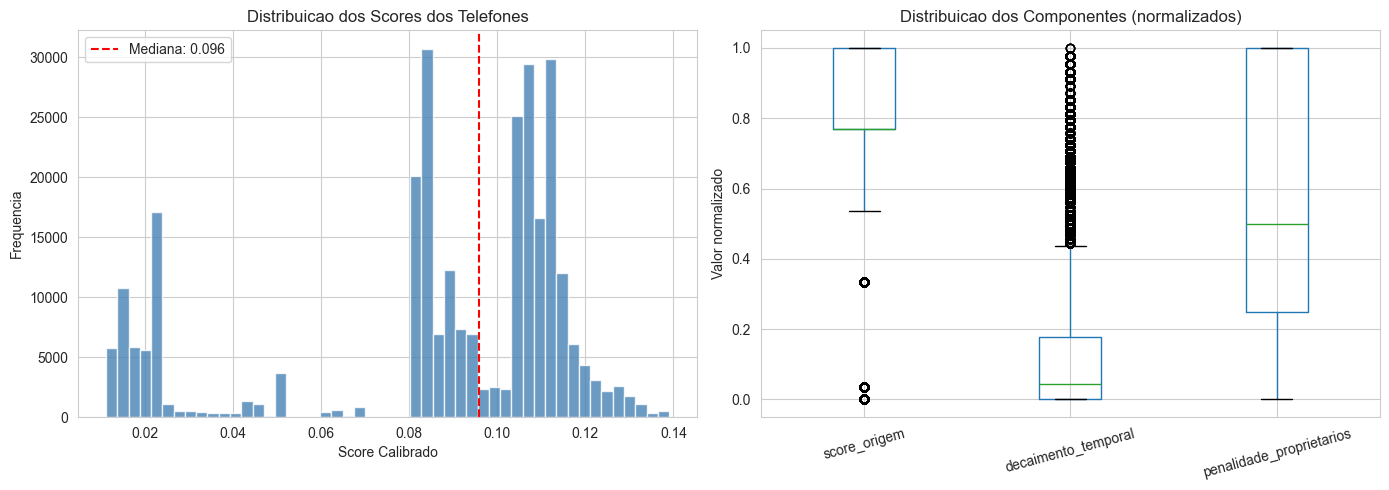

In [14]:
# ============================================================
# 6.2 DISTRIBUICAO DOS SCORES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_features['score_calibrado'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df_features['score_calibrado'].median(), color='red', linestyle='--', 
                label=f'Mediana: {df_features["score_calibrado"].median():.3f}')
axes[0].set_xlabel('Score Calibrado')
axes[0].set_ylabel('Frequencia')
axes[0].set_title('Distribuicao dos Scores dos Telefones')
axes[0].legend()

components = df_features[['score_origem', 'decaimento_temporal', 'penalidade_proprietarios']].copy()
components_norm = (components - components.min()) / (components.max() - components.min())
components_norm.boxplot(ax=axes[1])
axes[1].set_title('Distribuicao dos Componentes (normalizados)')
axes[1].set_ylabel('Valor normalizado')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# 6.3 ALGORITMO DE ESCOLHA DOS 2 MELHORES POR CPF
# ============================================================
def extrair_cpfs_do_telefone(aparicoes):
    if isinstance(aparicoes, (list, np.ndarray)):
        cpfs = [a['cpf'] for a in aparicoes if 'cpf' in a and a['cpf'] is not None]
        return list(set(cpfs))
    return []

# Extrair CPFs para cada telefone
df_telefone['cpfs'] = df_telefone['telefone_aparicoes'].apply(extrair_cpfs_do_telefone)

# Explodir: uma linha por (telefone, cpf)
df_telefone_cpf = df_telefone[['telefone_numero', 'cpfs']].explode('cpfs')
df_telefone_cpf = df_telefone_cpf.rename(columns={'cpfs': 'cpf'})
df_telefone_cpf = df_telefone_cpf.dropna(subset=['cpf'])

# Merge com scores
df_telefone_cpf = df_telefone_cpf.merge(
    df_features[['telefone_numero', 'score_calibrado', 'dias_atualizacao', 'n_proprietarios']],
    on='telefone_numero',
    how='left'
)

print('Total de relacoes (telefone, cpf):', len(df_telefone_cpf))
print('CPFs unicos:', df_telefone_cpf['cpf'].nunique())

# Escolher os 2 melhores por CPF
df_telefone_cpf_sorted = df_telefone_cpf.sort_values(
    ['cpf', 'score_calibrado', 'dias_atualizacao', 'n_proprietarios'],
    ascending=[True, False, True, True]
)

melhores_por_cpf = df_telefone_cpf_sorted.groupby('cpf').head(2).reset_index(drop=True)

print('Total de telefones escolhidos:', len(melhores_por_cpf))
print('CPFs com 2 telefones:', (melhores_por_cpf.groupby('cpf').size() == 2).sum())
print('CPFs com 1 telefone:', (melhores_por_cpf.groupby('cpf').size() == 1).sum())

melhores_por_cpf.head(10)

Total de relacoes (telefone, cpf): 1253916


CPFs unicos: 1221517


Total de telefones escolhidos: 1252434


CPFs com 2 telefones: 30917


CPFs com 1 telefone: 1190600


,telefone_numero,cpf,score_calibrado,dias_atualizacao,n_proprietarios
0,3786979291099202786,-9223357153522839002,0.081345,307.0,39.0
1,-78249539818182761,-9223348033465467038,0.109713,213.0,4.0
2,-7334860579917592921,-9223342154106039849,0.113397,193.0,4.0
3,-846384703661013523,-9223336070559283926,0.104992,302.0,3.0
4,9207645784433573265,-9223326362687976865,0.107876,228.0,4.0
5,7206527119626867145,-9223320876670338686,0.104666,263.0,6.0
6,8927337164312514953,-9223318765562443424,0.023397,2339.0,1.0
7,1369454642408001720,-9223313997615342860,0.092268,198.0,3.0
8,2035460933536494857,-9223309126695839296,0.093768,198.0,2.0
9,6961795766105329307,-9223257806326846520,0.011126,532.0,17908.0


In [16]:
# ============================================================
# 6.4 ESTRUTURA FINAL DO OUTPUT
# ============================================================
melhores_por_cpf['rank'] = melhores_por_cpf.groupby('cpf').cumcount() + 1

resultado_final = melhores_por_cpf.pivot(
    index='cpf',
    columns='rank',
    values=['telefone_numero', 'score_calibrado']
)

resultado_final.columns = [f'{col[0]}_{col[1]}' for col in resultado_final.columns]
resultado_final = resultado_final.reset_index()

resultado_final = resultado_final.rename(columns={
    'telefone_numero_1': 'telefone_1',
    'score_calibrado_1': 'score_1',
    'telefone_numero_2': 'telefone_2',
    'score_calibrado_2': 'score_2',
})

print('Resultado final:', len(resultado_final), 'CPFs')
print('Com 2 telefones:', resultado_final['telefone_2'].notna().sum())
print('Apenas 1 telefone:', resultado_final['telefone_2'].isna().sum())

resultado_final.head(10)

Resultado final: 1221517 CPFs
Com 2 telefones: 30917
Apenas 1 telefone: 1190600


,cpf,telefone_1,telefone_2,score_1,score_2
0,-9223357153522839002,3.786979e+18,NaN,0.081345,NaN
1,-9223348033465467038,-7.824954e+16,NaN,0.109713,NaN
2,-9223342154106039849,-7.334861e+18,NaN,0.113397,NaN
3,-9223336070559283926,-8.463847e+17,NaN,0.104992,NaN
4,-9223326362687976865,9.207646e+18,NaN,0.107876,NaN
5,-9223320876670338686,7.206527e+18,NaN,0.104666,NaN
6,-9223318765562443424,8.927337e+18,NaN,0.023397,NaN
7,-9223313997615342860,1.369455e+18,NaN,0.092268,NaN
8,-9223309126695839296,2.035461e+18,NaN,0.093768,NaN
9,-9223257806326846520,6.961796e+18,NaN,0.011126,NaN


---
## 7. Validacao do Algoritmo

Comparar o desempenho do algoritmo contra um **baseline aleatorio**.

In [17]:
# ============================================================
# 7.1 SIMULACAO: TAXA DE LEITURA DOS TELEFONES ESCOLHIDOS
# ============================================================
taxas_historicas = df_disparo.groupby('contato_telefone')['status_disparo'].apply(
    lambda x: (x == 'read').mean()
).reset_index()
taxas_historicas.columns = ['telefone_numero', 'taxa_leitura_historica']

escolhas_t1 = resultado_final[['cpf', 'telefone_1', 'score_1']].merge(
    taxas_historicas, left_on='telefone_1', right_on='telefone_numero', how='left'
).drop(columns=['telefone_numero'])

escolhas_t2 = resultado_final[['cpf', 'telefone_2', 'score_2']].merge(
    taxas_historicas, left_on='telefone_2', right_on='telefone_numero', how='left'
).drop(columns=['telefone_numero'])

taxa_algo_t1 = escolhas_t1['taxa_leitura_historica'].mean()
taxa_algo_t2 = escolhas_t2['taxa_leitura_historica'].mean()

print('=== TAXA DE LEITURA DOS TELEFONES ESCOLHIDOS ===')
print('Telefone 1 (melhor):', f'{taxa_algo_t1:.2%}')
print('Telefone 2 (segundo):', f'{taxa_algo_t2:.2%}')
print('Media ponderada:', f'{(taxa_algo_t1 + taxa_algo_t2)/2:.2%}')

taxa_media_geral = taxas_historicas['taxa_leitura_historica'].mean()
print('Taxa media geral (baseline):', f'{taxa_media_geral:.2%}')
print('Uplift do algoritmo vs baseline:', f'{(taxa_algo_t1 - taxa_media_geral):.2%}')

=== TAXA DE LEITURA DOS TELEFONES ESCOLHIDOS ===
Telefone 1 (melhor): 66.04%
Telefone 2 (segundo): 60.02%
Media ponderada: 63.03%
Taxa media geral (baseline): 70.01%
Uplift do algoritmo vs baseline: -3.97%


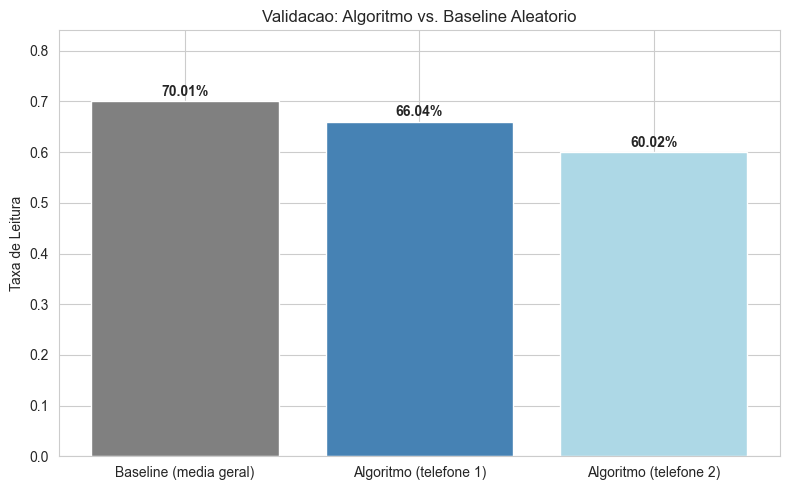

Nota: Esta e uma validacao aproximada usando dados historicos.
O teste A/B real sera proposto no Notebook 03.


In [18]:
# ============================================================
# 7.2 COMPARACAO VISUAL: ALGORITMO VS BASELINE
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

categorias = ['Baseline (media geral)', 'Algoritmo (telefone 1)', 'Algoritmo (telefone 2)']
taxas = [taxa_media_geral, taxa_algo_t1, taxa_algo_t2]
cores = ['gray', 'steelblue', 'lightblue']

bars = ax.bar(categorias, taxas, color=cores, edgecolor='white')
ax.set_ylabel('Taxa de Leitura')
ax.set_title('Validacao: Algoritmo vs. Baseline Aleatorio')
ax.set_ylim(0, max(taxas) * 1.2)

for bar, taxa in zip(bars, taxas):
    if not np.isnan(taxa):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{taxa:.2%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print('Nota: Esta e uma validacao aproximada usando dados historicos.')
print('O teste A/B real sera proposto no Notebook 03.')

---
## 8. Sumario da Parte 2 — Entregaveis

### Algoritmo de Escolha

O algoritmo proposto combina 3 componentes em um score calibrado:

| Componente | Descricao | Peso Calibrado |
|---|---|---|
| `score_origem` | Wilson Lower Bound do melhor sistema | Calculado via Regressao Logistica |
| `decaimento_temporal` | Exponencial decrescente (half-life otimizado) | Calculado via Regressao Logistica |
| `penalidade_proprietarios` | 1 / n_proprietarios | Calculado via Regressao Logistica |

**Half-life otimizado:** calculado via grid search comparando capacidade preditiva
(AUC-ROC, LogLoss, MCC) com split temporal.

**Lógica de decisao:**
1. Para cada CPF, listar todos os telefones associados
2. Calcular score de cada telefone usando pesos calibrados
3. Escolher os 2 telefones com maior score
4. Em empate: desempatar por atualidade mais recente, depois menos proprietarios

### Metricas de Capacidade Preditiva

| Metrica | Valor | Interpretacao |
|---|---|---|
| AUC-ROC | (calculado) | Discriminacao entre read e nao-read |
| LogLoss | (calculado) | Calibracao probabilistica |
| MCC | (calculado) | Correlacao robusta (classes desbalanceadas) |
| Acuracia | (calculado) | Taxa de classificacao correta |

### Limitacoes Documentadas
- Regressao logistica assume linearidade no log-odds
- Pesos refletem padroes historicos, que podem conter viés de selecao
- Validacao aproximada; teste A/B real definira se o algoritmo de fato melhora
- Telefones sem sistema de origem recebem score_origem = 0

In [19]:
# ============================================================
# 8.1 SALVAR ARTEFATOS PARA NOTEBOOK 03
# ============================================================
OUTPUT_DIR = u.BASE_DIR / 'data' / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

artefatos = {
    'resultado_escolha': resultado_final,
    'telefones_com_score': df_features,
    'pesos_calibrados': pesos_df,
    'modelo_logistico': modelo_final,
    'scaler': scaler_final,
}

for nome, obj in artefatos.items():
    caminho = OUTPUT_DIR / f'{nome}.pkl'
    with open(caminho, 'wb') as f:
        pickle.dump(obj, f)
    print(f'{nome} salvo em {caminho}')

print('Artefatos da Parte 2 salvos. Proximo: Notebook 03 - Desenho do Experimento.')

resultado_escolha salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\resultado_escolha.pkl
telefones_com_score salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\telefones_com_score.pkl
pesos_calibrados salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\pesos_calibrados.pkl
modelo_logistico salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\modelo_logistico.pkl
scaler salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\scaler.pkl
Artefatos da Parte 2 salvos. Proximo: Notebook 03 - Desenho do Experimento.
